**Project:** Data Mining II (2025/26)

**Group Number:** 12

**Members:**
- Beatriz Boura - 20250272
- Dinis Gaspar - 20221869
- Margarida Cruz - 20221929

**Project Overview**

In recent years, nonprofit organizations have faced a growing challenge: while charitable causes have multiplied, public tolerance for repeated, generic solicitations has significantly decreased, often leading to donor fatigue and long-term disengagement. To address this issue, the Civic Support Alliance (CSA)—a federation representing multiple humanitarian and social aid programs—seeks to modernize its fundraising strategy. Rather than launching blanket campaigns across their entire database, the organization aims to transition to a highly targeted approach. The goal is to maximize operational efficiency and maintain donor respect by contacting fewer, but more receptive, individuals. 

As data scientists, our team has been tasked with building a predictive machine learning system using historical demographic, interaction, and donation data accumulated from past campaigns. The primary objective is to accurately answer a fundamental question: Will this person donate if contacted? 

**Notebook Introduction**

In this final notebook of our project, we will analyze the pipelines we have produced and decide on a best one. We will then showcase the interactive dashboard we have designed to help the CSA and its agents achieve donations. To conclude we will wrap-up the project with a general conclusion.

**Table of contents**<a id='toc0_'></a>    
1. [Imports](#toc1_)    
2. [Final Pipeline Selection](#toc2_)    
3. [Interactive Streamlit Dashboard](#toc3_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=true
	minLevel=1
	maxLevel=3
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# 1. <a id='toc1_'></a>[Imports](#toc0_)

In this section we import the needed tools and libraries.

In [70]:
from utils_modeling import (OutlierClipper, CategoricalFeatureSelector, NumericalFeatureSelector, FeatureEngineer, DataCleaner)
import os
# Adding this ensures that the magic command only runs once (the first time)
if os.getcwd().split('\\')[-1] != 'DM2_Project':
    %cd ..
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.options.display.max_columns = None

In [71]:
train = pd.read_csv('Files/donors_train.csv')

# 2. <a id='toc2_'></a>[Final Pipeline Selection](#toc0_)

Here, we will analyze the results obtained by our final pipelines from the parameter search of each type of model and decide on what our final, definitive pipeline solution is. We'll start by importing the Kaggle results dataframe and analyzing it.

In [72]:
kaggle_results_df = pd.read_pickle('Files/Pickle Files/Kaggle_scores.pkl')
# Sorting to get the highest cross-validated F1-scores at the top
kaggle_results_df.sort_values('CV Mean Val F1', ascending=False)

,Kaggle Public Score,Submission File Name,CV Mean Val F1,CV Mean Train F1
Best RF Pipeline,0.43304,DM2DT_Group12_Version22.csv,0.421884,0.461440
Best LR Pipeline,0.43087,DM2DT_Group12_Version25.csv,0.421687,0.423902
Best GB Pipeline,0.43478,DM2DT_Group12_Version24.csv,0.420412,0.466219
Best NB Pipeline,0.42893,DM2DT_Group12_Version20.csv,0.419758,0.419638
Best NN Pipeline,0.43264,DM2DT_Group12_Version29.csv,0.418193,0.421301
Best AdaBoost Pipeline,0.43735,DM2DT_Group12_Version23.csv,0.412953,0.416364
Best DT Pipeline,0.41582,DM2DT_Group12_Version19.csv,0.411342,0.415477
Best KNN Pipeline,0.42145,DM2DT_Group12_Version18.csv,0.410642,0.431648


In [73]:
# Sorting to get the highest Kaggle Public Scores at the top
kaggle_results_df.sort_values('Kaggle Public Score', ascending=False)

,Kaggle Public Score,Submission File Name,CV Mean Val F1,CV Mean Train F1
Best AdaBoost Pipeline,0.43735,DM2DT_Group12_Version23.csv,0.412953,0.416364
Best GB Pipeline,0.43478,DM2DT_Group12_Version24.csv,0.420412,0.466219
Best RF Pipeline,0.43304,DM2DT_Group12_Version22.csv,0.421884,0.461440
Best NN Pipeline,0.43264,DM2DT_Group12_Version29.csv,0.418193,0.421301
Best LR Pipeline,0.43087,DM2DT_Group12_Version25.csv,0.421687,0.423902
Best NB Pipeline,0.42893,DM2DT_Group12_Version20.csv,0.419758,0.419638
Best KNN Pipeline,0.42145,DM2DT_Group12_Version18.csv,0.410642,0.431648
Best DT Pipeline,0.41582,DM2DT_Group12_Version19.csv,0.411342,0.415477


We will focus mainly on the cross-validation scores and will somewhat ignore the Kaggle scores, this is because the Kaggle Public score is only testing on 29% of the test data, meaning only ~1700 rows are used to compute that F1-Score, as such the cross-validation scores are more robust as they are averaged across 5 stratified folds of the training set, with each fold conataining over 2500 rows. This is further justified by the fact that our best performing model on Kaggle is actually one of three worst performing models in cross-validation scores.

Based on the validation F1-scores, there are 3 pipelines that jump out right away as the only ones with scores higher than 0.42 and thus the best candidates: RandomForest(0.421884), LogisticRegression(0.421687) and GradientBoosting(0.420412). Out of those three pipelines, we can exclude GradientBoosting quickly since it's the worst of the 3 on validation and also the one with highest gap between training validation scores. To decide between the two remaining models we will import their results dataframes so we can inspect them in more detail.

In [74]:
rf_results_df = pd.read_pickle('Files/Pickle Files/Results/RF_Gridsearch_Results.pkl')
lr_results_df = pd.read_pickle('Files/Pickle Files/Results/LR_Gridsearch_Results.pkl')
display(rf_results_df.head())
display(lr_results_df.head())

,params_config,model__estimator,model__estimator__max_depth,model__estimator__max_features,model__estimator__n_estimators,preprocessing__num_section__clipper,preprocessing__num_section__imputer,preprocessing__num_section__scaler,mean_fit_time,mean_val_f1,std_val_f1,mean_train_f1,std_train_f1,mean_val_precision,std_val_precision,mean_train_precision,std_train_precision,mean_val_recall,std_val_recall,mean_train_recall,std_train_recall,status
125,{'model__estimator': RandomForestClassifier(cl...,RandomForestClassifier(class_weight='balanced'...,6,log2,100,OutlierClipper(iqr_multiplier=3),KNNImputer(n_neighbors=50),RobustScaler(),69.068055,0.421884,0.008525,0.461440,0.005948,0.289578,0.010960,0.317699,0.009656,0.779646,0.028457,0.846091,0.038424,Success
75,{'model__estimator': RandomForestClassifier(cl...,RandomForestClassifier(class_weight='balanced'...,6,sqrt,50,OutlierClipper(),KNNImputer(n_neighbors=50),PowerTransformer(),77.491940,0.421557,0.006330,0.465330,0.006629,0.290491,0.003355,0.321363,0.008461,0.769322,0.035010,0.844248,0.017216,Success
89,{'model__estimator': RandomForestClassifier(cl...,RandomForestClassifier(class_weight='balanced'...,6,sqrt,100,OutlierClipper(iqr_multiplier=3),KNNImputer(n_neighbors=50),RobustScaler(),69.728558,0.421001,0.006914,0.465796,0.006719,0.290568,0.005601,0.322102,0.009994,0.766077,0.040635,0.843215,0.025465,Success
303,{'model__estimator': RandomForestClassifier(cl...,RandomForestClassifier(class_weight='balanced'...,6,log2,150,OutlierClipper(),"IterativeImputer(initial_strategy='median', ra...",PowerTransformer(),160.557132,0.420619,0.004381,0.465749,0.008500,0.291754,0.005324,0.323355,0.011858,0.755457,0.036943,0.835029,0.026709,Success
110,{'model__estimator': RandomForestClassifier(cl...,RandomForestClassifier(class_weight='balanced'...,6,log2,50,None,KNNImputer(n_neighbors=50),RobustScaler(),73.665870,0.420255,0.006678,0.463204,0.006744,0.291620,0.004226,0.322285,0.010117,0.754572,0.046703,0.825516,0.027518,Success


,params_config,model__estimator,model__estimator__C,model__estimator__penalty,model__estimator__solver,preprocessing__num_section__clipper,preprocessing__num_section__imputer,preprocessing__num_section__scaler,mean_fit_time,mean_val_f1,std_val_f1,mean_train_f1,std_train_f1,mean_val_precision,std_val_precision,mean_train_precision,std_train_precision,mean_val_recall,std_val_recall,mean_train_recall,std_train_recall,status,model__estimator__l1_ratio
196,{'model__estimator': LogisticRegression(C=10.0...,"LogisticRegression(C=10.0, class_weight='balan...",0.1,l2,liblinear,OutlierClipper(),KNNImputer(n_neighbors=50),None,53.767990,0.421687,0.006042,0.423902,0.001852,0.291890,0.005588,0.293585,0.003145,0.760767,0.030958,0.763422,0.027184,Success,NaN
288,{'model__estimator': LogisticRegression(C=10.0...,"LogisticRegression(C=10.0, class_weight='balan...",10.0,l2,liblinear,None,KNNImputer(n_neighbors=50),None,56.666014,0.420596,0.007129,0.423303,0.003244,0.286132,0.005562,0.288058,0.002413,0.793805,0.016749,0.798304,0.017383,Success,NaN
184,{'model__estimator': LogisticRegression(C=10.0...,"LogisticRegression(C=10.0, class_weight='balan...",0.1,l2,lbfgs,OutlierClipper(),KNNImputer(n_neighbors=50),None,59.068137,0.420504,0.005515,0.423605,0.002349,0.289064,0.006446,0.290881,0.004860,0.772861,0.030241,0.780973,0.032958,Success,NaN
9,{'model__estimator': LogisticRegression(C=10.0...,"LogisticRegression(C=10.0, class_weight='balan...",0.1,l1,saga,OutlierClipper(iqr_multiplier=3),KNNImputer(n_neighbors=50),PowerTransformer(),81.738942,0.420409,0.003169,0.424470,0.002152,0.290623,0.007233,0.293362,0.008079,0.764602,0.053396,0.771976,0.048072,Success,NaN
208,{'model__estimator': LogisticRegression(C=10.0...,"LogisticRegression(C=10.0, class_weight='balan...",0.1,NaN,lbfgs,OutlierClipper(),KNNImputer(n_neighbors=50),None,60.238530,0.420368,0.006547,0.423222,0.002782,0.292034,0.006796,0.293920,0.004061,0.751032,0.023936,0.756711,0.024147,Success,NaN


To reach a definitive decision, there are four main points we're going to take into account, outright validation performance, quality of fit, pipeline run-time interpretability:
+ Performance:
    - By looking at the standard deviations of scores, we can say both models have stable results.
    - The best RandomForest model achieves a higher cross-validated F1-score by 0.000197, which is quite a small difference, however when the problem is as difficult and low-scoring as this one, a seemingly insignifcant difference becomes more relevant. 
    - The RandomForest Pipeline also achieves a higher recall than the LogisticRegression pipeline by ~0.019 but a slighly lower precision by 0.0023. This means that it is better at finding true donors, with the slight cost of also contacting slightly more donors who won't donate. However, gap between recall is considerably larger than the precision gap (even when considering the fact that one is much higher and as such gaps will also be bigger). Considering the goal of the CSA is ultimately to generate donations, while optmizing their contact process, the compromise provided by the RandomForest pipeline is slightly more satisfactory.
+ Quality of fit:
    - When it comes to the quality of the fit, the LogisticRegression pipeline has a very solid fit, if not almost undefitting, with mean train and validation scores being almost identical.
    - The RandomForest pipeline does have a small gap of ~0.04 between training and validation scores, which must be considered for this decision, but is also not a massive problem since a 0.04 overfit on a tree-based model is generally considered quite acceptable.
+ Pipeline run-time:
    - The run-time of the LogisticRegression pipeline is decently faster, around 78% of the run-time of the RandomForest pipeline
+ Pipeline Interpretability:
    - Traditionally, LogisticRegression based pipelines are extremely interpretable, but in this case since our parameter search, somewhat unexpectedly, showed that a LogisticRegression pipeline with no scaling was actually the best option that interpretability is mostly lost since coefficients can't be directly compared due to feature scale.
    - Therefore, the RandomForest pipeline, since it uses a tree-based model, is actually the most interpretable of the two options.

**Verdict:** With all of the considerations above taken into account, we believe that the best pipeline we have developed is the RandomForest pipeline. This is due to three main reason, the difficulty of the problem and low scores, where even a small increase is crucial, the fact that even though there is some overfitting 0.04 is not at all unnaceptable for a tree-based model and finally, the fact that it is a more interpretable mode, where feature importances can be more easily looked at. We will import it below and produce a feature importance plot analyzing the implications.


In [75]:
with open('Files/Pickle Files/Pipelines/RF_GridSearch_Best_Pipeline.pkl', 'rb') as file:
    rf_best_pipeline = pickle.load(file)
rf_best_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cleaner', ...), ('preprocessing', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,categorical_cols_values,"{'DONOR_GENDER': ['M', 'F', ...], 'INCOME_GROUP': array([1, 2, 3, 4, 5, 6, 7]), 'PEP_STAR': [0, 1], 'RECENCY_STATUS_96NK': ['S', 'A', ...], ...}"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_section', ...), ('num_section', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that

In [76]:
# To get the correct feature importances for each feature, we need to access what columns
# are selected by the pipeline. We got to the second to last step and use the get_feature_names_out
# method (the last step, the model, doesn't have a get_features_out).
final_pipeline_precossed_cols = rf_best_pipeline[:-1].get_feature_names_out()

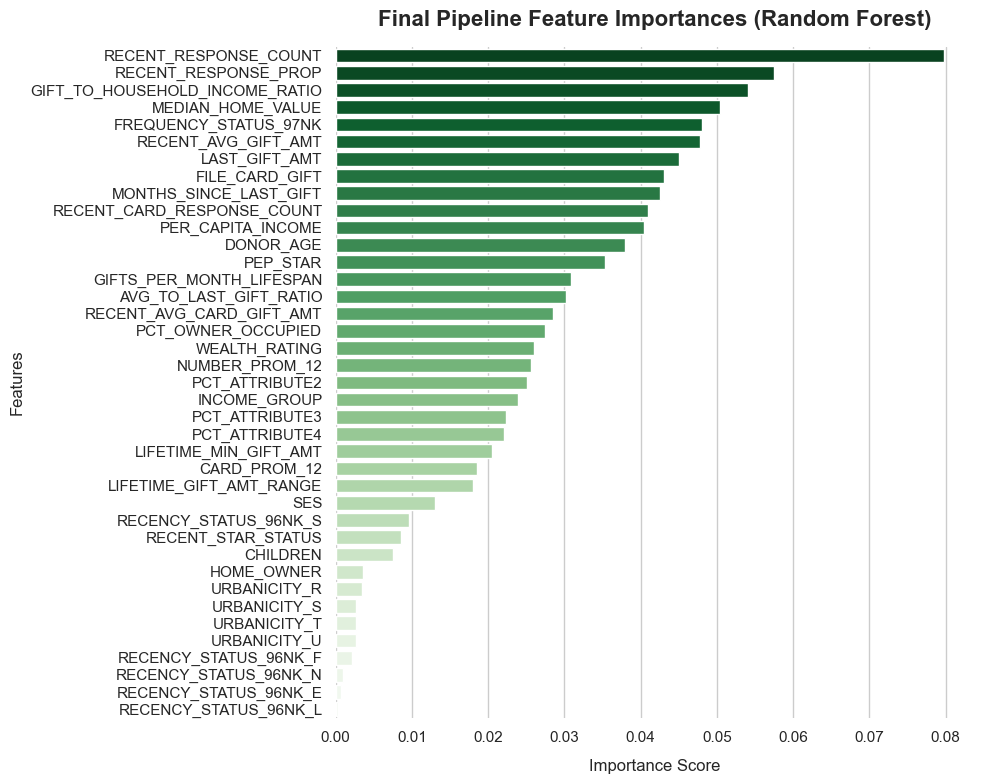

In [77]:
# Creating importances_df dataframe with feature importances
# We use ['model'].estimator_ to extract the fitted RandomForest from the TunedThresholdClassifierCV
importances_df = pd.DataFrame({"feature_names" : final_pipeline_precossed_cols,
                               "importances" : rf_best_pipeline['model'].estimator_.feature_importances_})

# Sorting the dataframe by importances in descending order
importances_df = importances_df.sort_values(by="importances", ascending=False).reset_index(drop=True)

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# Plot a horizontal bar chart
ax = sns.barplot(
    x="importances", 
    y="feature_names", 
    data=importances_df, 
    palette="Greens_r"
    )

# Customize titles and labels clearly
ax.set_title("Final Pipeline Feature Importances (Random Forest)", fontsize=16, pad=15, fontweight='bold')
ax.set_xlabel("Importance Score", fontsize=12, labelpad=10)
ax.set_ylabel("Features", fontsize=12)

# Clean up spines
sns.despine(left=True, bottom=True)

# Adjust layout and show
plt.tight_layout()
plt.show()

Main Conclusions:

+ Recent Interaction Frequency is key: The highest peak in the chart belongs to RECENT_RESPONSE_COUNT (followed closely by RECENT_RESPONSE_PROP). This indicates that a donor’s recent engagement history and willingness to respond to promotions over the last four years is the strongest predictor of whether they will donate again.
+ Recent Behavior Beats Lifetime Volume: Features tracking recent activity are significantly more important than long-term lifetime metrics like LIFETIME_MIN_GIFT_AMT or total historical counts. The model prioritizes current momentum over distant history.
+ Neighborhood and Localized Wealth: Baseline economic indicators of the donor's area—specifically MEDIAN_HOME_VALUE and PER_CAPITA_INCOME—rank as critical features. The model relies heavily on these regional financial profiles to assess overall donor capability.
+ The Power of Engineered Socio-Economic Proxies: The feature GIFT_TO_HOUSEHOLD_INCOME_RATIO ranks exceptionally high, validating the feature engineering strategy. By standardizing a donor's average gift against their neighborhood's median household income, this feature acts as a strong proxy for relative generosity and commitment, proving far more predictive than raw income or baseline donation amounts alone.
+ Temporal Dynamics vs. Basic Ratios: Among the engineered features, GIFTS_PER_MONTH_LIFESPAN captures meaningful variance by exposing high-velocity supporters (those with compressed giving windows). This temporal frequency metric proves more valuable to the model than static historical spreads like LIFETIME_GIFT_AMT_RANGE.
+ Low Impact Features: Features such as specific one-hot encoded RECENCY_STATUS_96NK flags and URBANICITY categories, meaning they don't prove to be crucial for donor behavior.


**Strategic Implications for the  Civic Support Alliance:** This predictive framework transitions the Civic Support Alliance (CSA) from a costly, blanket mass-marketing approach to an optimized, high-yield targeting strategy. By isolating high-conversion donor segments—specifically, individuals with strong recent engagement momentum, localized financial stability, and a high propensity for relative generosity—the CSA can drastically reduce operational outreach costs while simultaneously defending the brand against donor campaign fatigue. This directly maximizes marketing ROI and satisfies the core strategic mandate of contacting fewer individuals while increasing overall conversion rates.

# 3. <a id='toc3_'></a>[Interactive Streamlit Dashboard](#toc0_)


https://2526-mgiday-dm2-group12-csa-dashboard.streamlit.app/